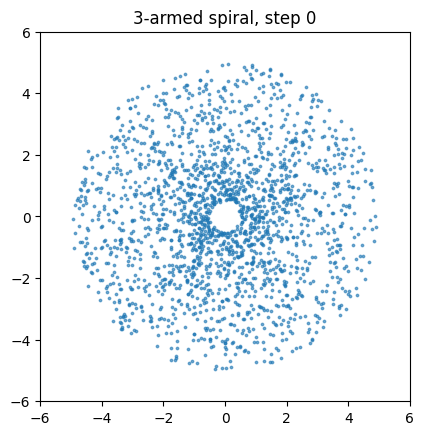

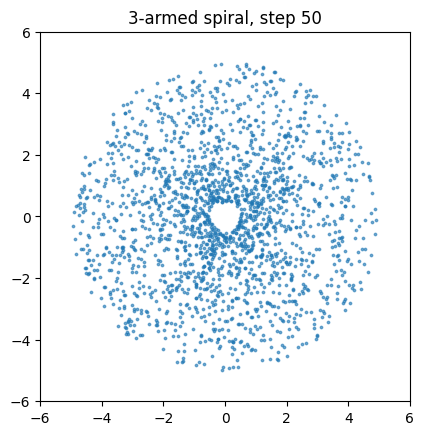

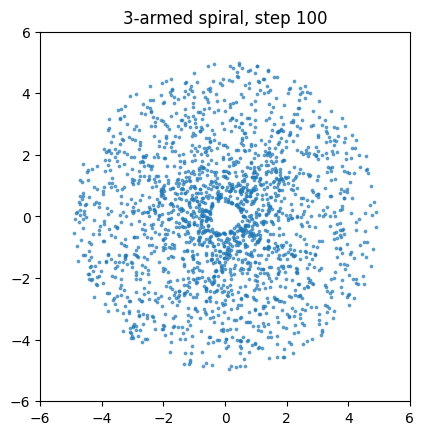

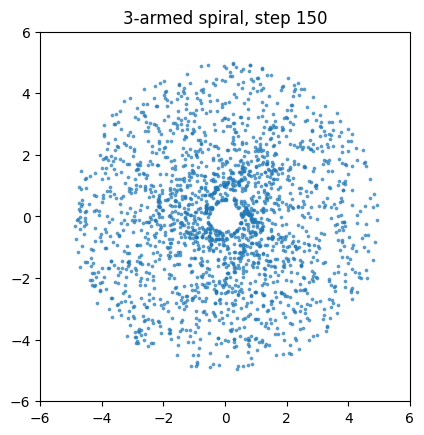

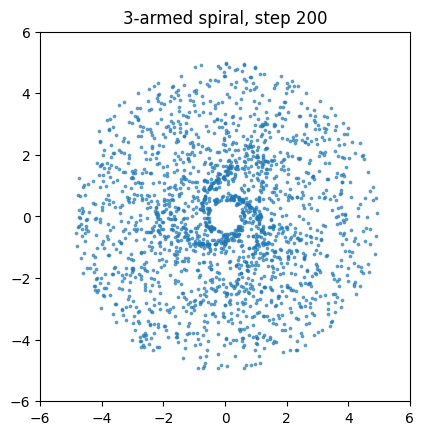

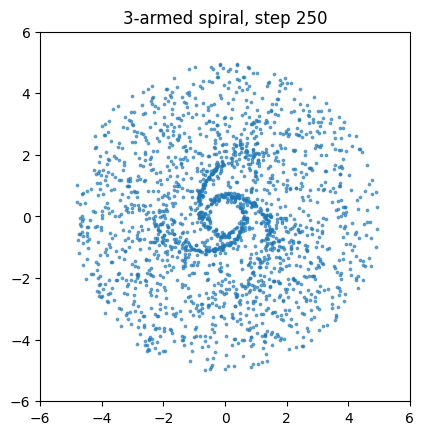

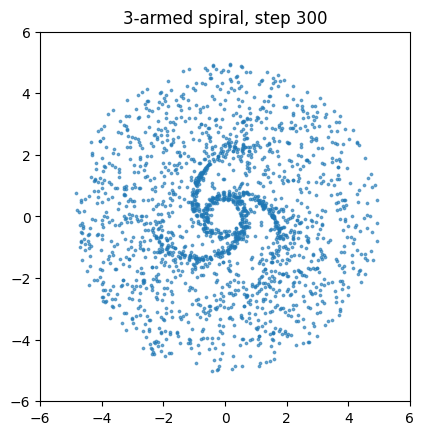

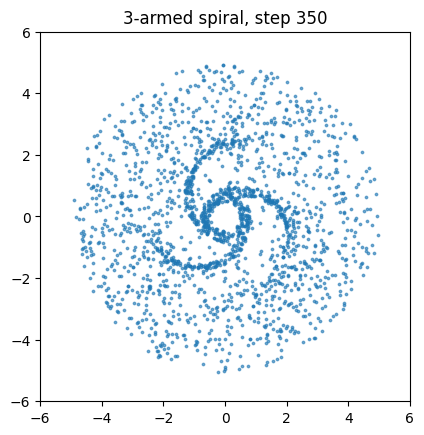

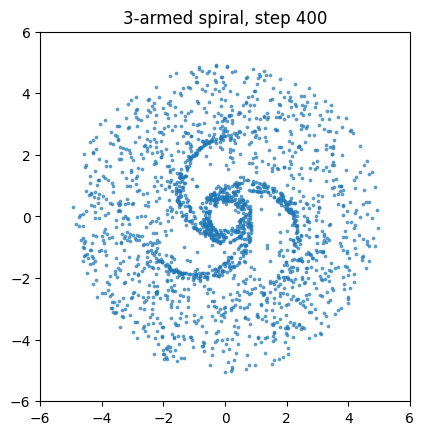

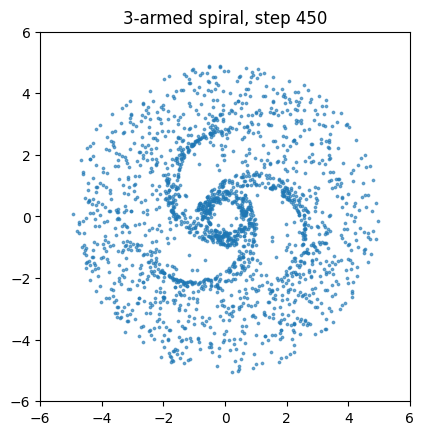

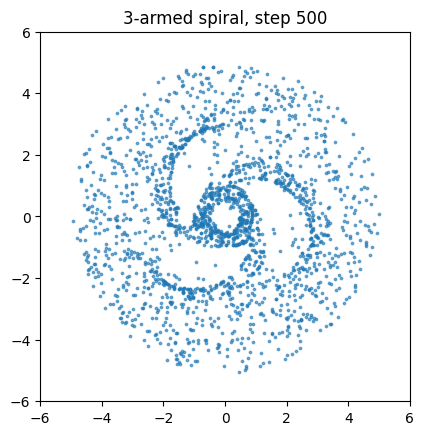

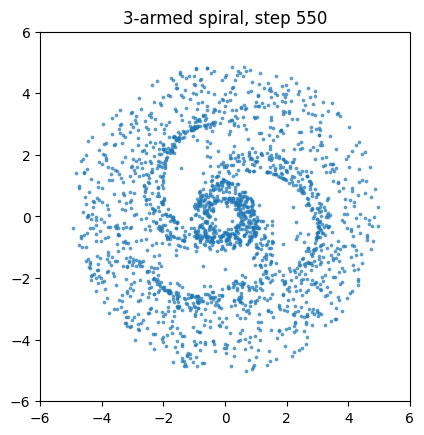

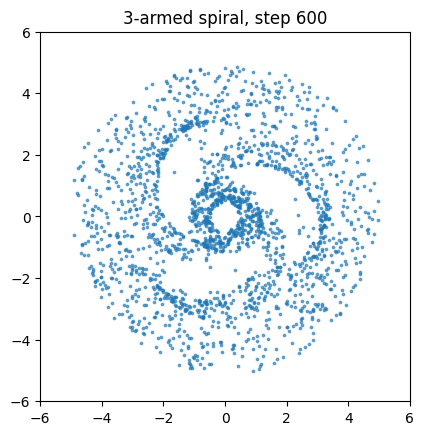

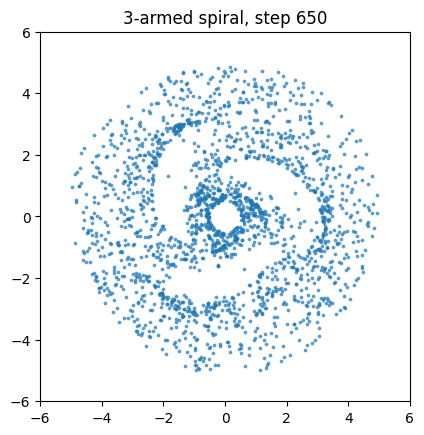

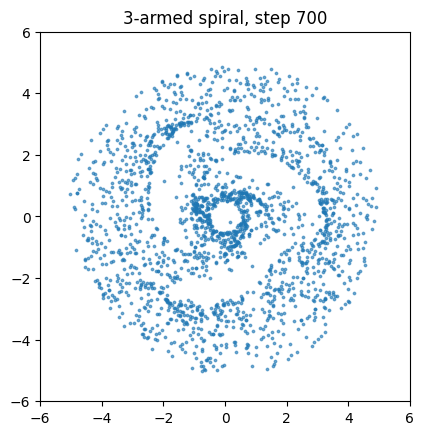

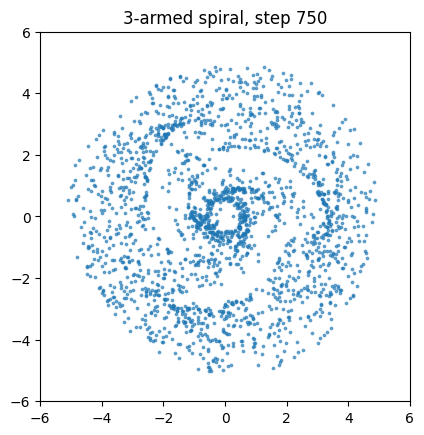

In [3]:
import numpy as np
import matplotlib.pyplot as plt

G = 1.0
M_star = 1.0
dt = 0.01

# -----------------------------
# USER PARAMETER: number of arms
# -----------------------------
N_arms = 3          # <--- change this
eps_spiral = 0.05   # strength of spiral forcing
Omega_p = 0.6       # pattern speed (controls winding)
softening = 0.2

def initialize_disk(N=2000):
    r = np.random.uniform(0.5, 5, N)
    theta = np.random.uniform(0, 2*np.pi, N)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    v = np.sqrt(G * M_star / r)
    vx = -v * np.sin(theta)
    vy =  v * np.cos(theta)

    return x, y, vx, vy


def spiral_acceleration(x, y, t, m):
    """
    Rotating m-armed spiral potential:
    Phi ~ cos(m(theta - Omega_p t))
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    phase = m * (theta - Omega_p * t)

    # radial and azimuthal components of perturbation
    ar = -(eps_spiral * m / (r + softening)) * np.sin(phase)
    a_theta = (eps_spiral * m / (r + softening)) * np.cos(phase)

    ax = ar * np.cos(theta) - a_theta * np.sin(theta)
    ay = ar * np.sin(theta) + a_theta * np.cos(theta)

    return ax, ay


def step(x, y, vx, vy, t, drag=0.000):
    r = np.sqrt(x**2 + y**2)

    # Central gravity
    ax = -G * M_star * x / (r**3 + 1e-8)
    ay = -G * M_star * y / (r**3 + 1e-8)

    # damping (optional)
    ax -= drag * vx
    ay -= drag * vy

    # spiral forcing (THIS is what creates N arms)
    ax_sp, ay_sp = spiral_acceleration(x, y, t, N_arms)
    ax += ax_sp
    ay += ay_sp

    # integrate
    vx += ax * dt
    vy += ay * dt

    x += vx * dt
    y += vy * dt

    return x, y, vx, vy


# -----------------------------
# initialize
# -----------------------------
x, y, vx, vy = initialize_disk()

# -----------------------------
# evolve
# -----------------------------
T = 800
for i in range(T):
    t = i * dt
    x, y, vx, vy = step(x, y, vx, vy, t)

    if i % 50 == 0:
        plt.clf()
        plt.scatter(x, y, s=3, alpha=0.6)
        plt.gca().set_aspect('equal')
        plt.title(f"{N_arms}-armed spiral, step {i}")
        plt.xlim(-6, 6)
        plt.ylim(-6, 6)
        plt.pause(0.01)

plt.show()

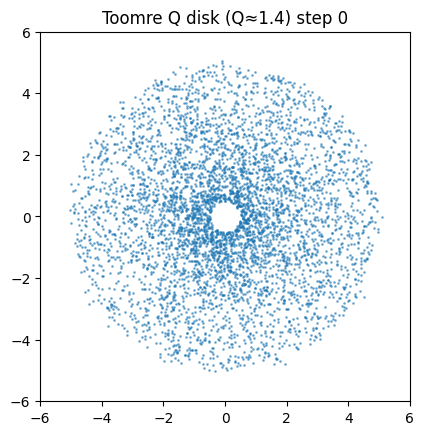

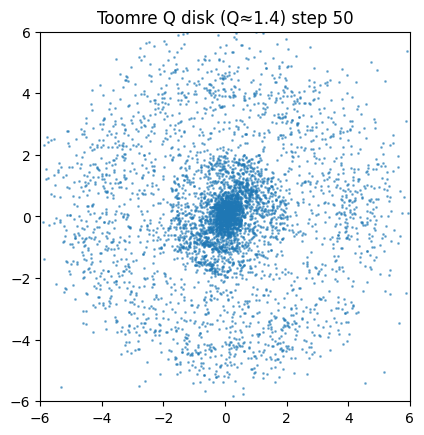

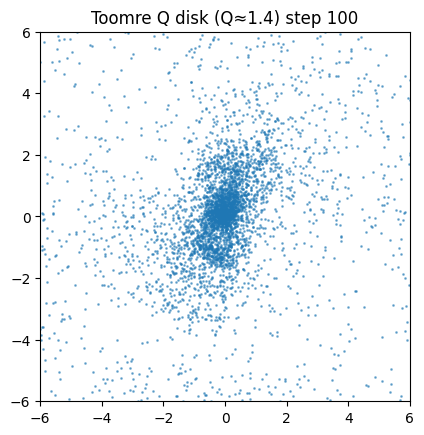

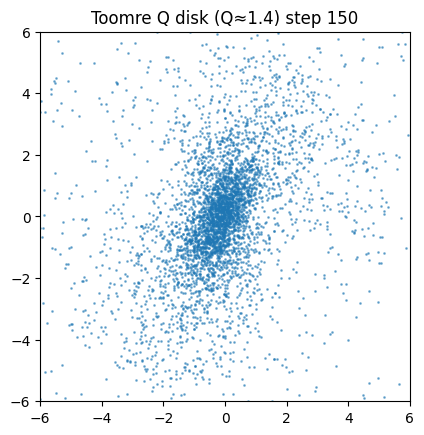

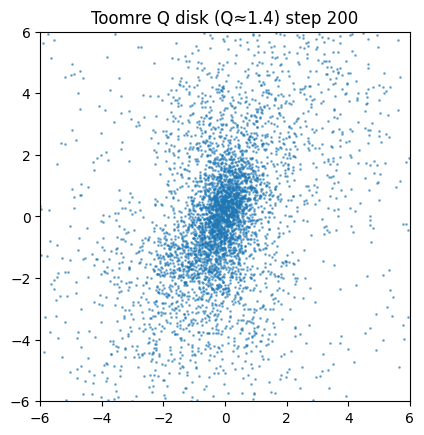

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

G = 1.0
M_star = 1.0
dt = 0.01

# -----------------------------
# USER PARAMETERS
# -----------------------------
N_particles = 5000        # IMPORTANT: higher N reduces noise
Q_target = 1.4            # 1.2–1.8 is spiral-active regime

softening = 0.3           # suppresses 2-body scattering
selfgrav_strength = 0.25  # weaker gravity prevents fragmentation

# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
def initialize_disk(N=5000):
    r = np.random.uniform(0.5, 5.0, N)
    theta = np.random.uniform(0, 2*np.pi, N)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Keplerian circular velocity
    vK = np.sqrt(G * M_star / r)

    vx = -vK * np.sin(theta)
    vy =  vK * np.cos(theta)

    # -----------------------------
    # Toomre-consistent velocity dispersion
    # (anisotropic: radial > azimuthal)
    # -----------------------------
    Sigma = 1.0 / (r + 0.5)
    kappa = vK / (r + 1e-8)

    sigma_r = Q_target * (3.36 * G * Sigma / (kappa + 1e-8))
    sigma_phi = 0.5 * sigma_r  # IMPORTANT: anisotropy prevents scattering

    vr = sigma_r * np.random.normal(0, 1, N)
    vphi = sigma_phi * np.random.normal(0, 1, N)

    vx += vr * np.cos(theta) - vphi * np.sin(theta)
    vy += vr * np.sin(theta) + vphi * np.cos(theta)

    return x, y, vx, vy


# -----------------------------
# CENTRAL FORCE
# -----------------------------
def central_force(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -G * M_star * x / (r**3 + 1e-8)
    ay = -G * M_star * y / (r**3 + 1e-8)
    return ax, ay


# -----------------------------
# SOFTENED SELF-GRAVITY
# (critical for suppressing noise heating)
# -----------------------------
def self_gravity(x, y):
    ax = np.zeros_like(x)
    ay = np.zeros_like(y)

    for i in range(len(x)):
        dx = x[i] - x
        dy = y[i] - y

        r2 = dx*dx + dy*dy + softening**2
        inv_r3 = r2**(-1.5)

        ax[i] -= np.sum(G * dx * inv_r3)
        ay[i] -= np.sum(G * dy * inv_r3)

    return ax, ay


# -----------------------------
# TIME STEP
# -----------------------------
def step(x, y, vx, vy):
    ax, ay = central_force(x, y)

    # self-gravity (reduced strength)
    ax_sg, ay_sg = self_gravity(x, y)
    ax += selfgrav_strength * ax_sg
    ay += selfgrav_strength * ay_sg

    vx += ax * dt
    vy += ay * dt

    x += vx * dt
    y += vy * dt

    return x, y, vx, vy


# -----------------------------
# RUN SIMULATION
# -----------------------------
x, y, vx, vy = initialize_disk(N_particles)

for i in range(1500):
    x, y, vx, vy = step(x, y, vx, vy)

    if i % 50 == 0:
        plt.clf()
        plt.scatter(x, y, s=1, alpha=0.5)
        plt.gca().set_aspect('equal')
        plt.xlim(-6, 6)
        plt.ylim(-6, 6)
        plt.title(f"Toomre Q disk (Q≈{Q_target}) step {i}")
        plt.pause(0.01)

plt.show()